# Diversity-Regularized PSR
**Novel Direction:** Fix PSR's diversity collapse by adding an entropy bonus to the PSR loss.

**Based on:** *The Surprising Effectiveness of Negative Reinforcement in LLM Reasoning* (NeurIPS 2025)

**What this notebook does:**
- Trains a small GPT-2 model on a mini math-QA dataset
- Implements PSR, NSR, and the novel **Diversity-Regularized PSR (DR-PSR)** with entropy bonus
- Evaluates Pass@k for k ∈ {1, 4, 8} and plots entropy during training
- Shows DR-PSR recovers diversity lost by plain PSR

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate matplotlib numpy torch

In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda


## 1. Mini Math Dataset
We create a small synthetic arithmetic dataset so training finishes quickly.

In [3]:
# ── Tiny arithmetic dataset ───────────────────────────────────────────────────
# Format: "Q: {a} + {b} = ? A: {answer}"
# We keep this extremely small (50 problems) so it runs on free Colab/Kaggle

def make_dataset(n=50, seed=42):
    rng = random.Random(seed)
    problems = []
    for _ in range(n):
        a = rng.randint(1, 20)
        b = rng.randint(1, 20)
        answer = a + b
        prompt = f"Q: {a} + {b} = ? A:"
        correct = f" {answer}"
        # Generate a few wrong answers for rollouts
        wrongs = [f" {answer + rng.randint(1,5)}" for _ in range(3)]
        problems.append({"prompt": prompt, "correct": correct, "wrongs": wrongs})
    return problems

dataset = make_dataset(n=50)
print("Sample problem:", dataset[0])

Sample problem: {'prompt': 'Q: 4 + 1 = ? A:', 'correct': ' 5', 'wrongs': [' 8', ' 7', ' 7']}


## 2. Model & Tokenizer
We use GPT-2 (small, 124M) — fast to load and fine-tune on free GPUs.

In [4]:
# ── Load GPT-2 ────────────────────────────────────────────────────────────────
MODEL_NAME = "gpt2"  # Use 'gpt2-medium' if you have more time/GPU

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

def fresh_model():
    m = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
    m.config.pad_token_id = tokenizer.eos_token_id
    return m.to(device)

print("Model loaded:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded: gpt2


## 3. Core RL Utilities
- `get_log_probs`: compute per-token log probabilities
- `compute_entropy`: token-level entropy (for DR-PSR bonus)
- `rollout`: generate k responses for a prompt
- `verify`: check if response is correct

In [5]:
def get_log_probs(model, input_ids, response_ids):
    """
    Returns log-probs for response_ids tokens given input_ids as prefix.
    input_ids: (1, L_prompt)  — prompt tokens
    response_ids: (1, L_resp) — response tokens
    Returns: scalar mean log-prob, and per-token probs tensor (L_resp, V)
    """
    full_ids = torch.cat([input_ids, response_ids], dim=1)  # (1, L_prompt + L_resp)
    with torch.no_grad():
        pass  # we do this with grad below

    outputs = model(full_ids)
    logits = outputs.logits  # (1, L, V)

    # We care about the response portion: positions [L_prompt-1 .. L_prompt+L_resp-2]
    # (each position predicts the NEXT token)
    L_prompt = input_ids.shape[1]
    L_resp = response_ids.shape[1]

    resp_logits = logits[0, L_prompt - 1: L_prompt + L_resp - 1, :]  # (L_resp, V)
    log_probs_all = F.log_softmax(resp_logits, dim=-1)  # (L_resp, V)

    # Gather log-probs for the actual response tokens
    resp_token_ids = response_ids[0]  # (L_resp,)
    token_log_probs = log_probs_all[range(L_resp), resp_token_ids]  # (L_resp,)

    mean_log_prob = token_log_probs.mean()
    return mean_log_prob, log_probs_all  # log_probs_all needed for entropy


def compute_token_entropy(log_probs_all):
    """
    log_probs_all: (L_resp, V) — log probabilities over vocabulary
    Returns: scalar mean entropy across response tokens
    """
    probs = log_probs_all.exp()  # (L_resp, V)
    entropy = -(probs * log_probs_all).sum(dim=-1)  # (L_resp,)
    return entropy.mean()


@torch.no_grad()
def rollout(model, prompt_ids, n_samples=8, max_new_tokens=10, temperature=1.0):
    """
    Generates n_samples responses for the given prompt.
    Returns list of response_ids tensors.
    """
    responses = []
    for _ in range(n_samples):
        out = model.generate(
            prompt_ids,
            max_new_tokens=max_new_tokens,
            do_sample=(temperature > 0),
            temperature=temperature,
            pad_token_id=tokenizer.eos_token_id,
        )
        resp_ids = out[:, prompt_ids.shape[1]:]  # strip prompt
        responses.append(resp_ids)
    return responses


def verify(response_ids, correct_answer_str):
    """
    Decodes response and checks if it contains the correct answer.
    Returns +1 for correct, -1 for incorrect.
    """
    decoded = tokenizer.decode(response_ids[0], skip_special_tokens=True).strip()
    correct = correct_answer_str.strip()
    return 1 if correct in decoded else -1


def compute_pass_at_k(model, problems, k_values=[1, 4, 8], n_samples=16, temperature=0.8):
    """
    Unbiased Pass@k estimator (Chen et al. 2021 formula).
    """
    results = defaultdict(list)
    model.eval()
    for prob in problems:
        prompt_ids = tokenizer.encode(prob["prompt"], return_tensors="pt").to(device)
        responses = rollout(model, prompt_ids, n_samples=n_samples, temperature=temperature)
        c = sum(1 for r in responses if verify(r, prob["correct"]) == 1)
        n = n_samples
        for k in k_values:
            if n - c < k:
                pass_k = 1.0
            else:
                # Unbiased estimator: 1 - C(n-c, k) / C(n, k)
                pass_k = 1.0 - math.comb(n - c, k) / math.comb(n, k)
            results[k].append(pass_k)
    return {k: np.mean(v) for k, v in results.items()}


print("Utilities defined.")

Utilities defined.


## 4. Training Functions

### Three objectives:
| Method | Loss |
|--------|------|
| **PSR** | Maximize log-prob of correct responses |
| **NSR** | Minimize log-prob of incorrect responses |
| **DR-PSR** *(Novel)* | PSR loss **−** β × token entropy (entropy bonus prevents collapse) |

In [6]:
def train_one_epoch(model, optimizer, problems, method="PSR", beta=0.02,
                    n_rollouts=4, temperature=1.0, max_new_tokens=8):
    """
    One epoch of training.
    method: 'PSR' | 'NSR' | 'DR_PSR' | 'FULL_RLVR'
    beta: entropy bonus coefficient (only used in DR_PSR)
    Returns: avg loss, avg entropy
    """
    model.train()
    total_loss = 0.0
    total_entropy = 0.0
    count = 0

    random.shuffle(problems)

    for prob in problems:
        prompt_ids = tokenizer.encode(prob["prompt"], return_tensors="pt").to(device)

        # --- Rollout: generate n_rollouts responses ---
        with torch.no_grad():
            responses = rollout(model, prompt_ids, n_samples=n_rollouts,
                                temperature=temperature, max_new_tokens=max_new_tokens)

        # --- Score each response ---
        correct_resp = [r for r in responses if verify(r, prob["correct"]) == 1]
        wrong_resp   = [r for r in responses if verify(r, prob["correct"]) == -1]

        # Skip if nothing to learn from
        if method == "PSR" and not correct_resp:
            continue
        if method == "NSR" and not wrong_resp:
            continue
        if method == "DR_PSR" and not correct_resp:
            continue
        if method == "FULL_RLVR" and not (correct_resp or wrong_resp):
            continue

        # --- Build loss ---
        optimizer.zero_grad()
        batch_loss = torch.tensor(0.0, device=device, requires_grad=True)
        batch_entropy = torch.tensor(0.0, device=device)

        def accumulate_loss(resp_list, sign):
            nonlocal batch_loss, batch_entropy
            for resp_ids in resp_list:
                mean_lp, lp_all = get_log_probs(model, prompt_ids, resp_ids)
                # sign=+1 → maximize log-prob (PSR) → loss = -log_prob
                # sign=-1 → minimize log-prob (NSR) → loss = +log_prob
                batch_loss = batch_loss + (-sign * mean_lp)
                if method == "DR_PSR":
                    ent = compute_token_entropy(lp_all)
                    batch_entropy = batch_entropy + ent

        if method == "PSR":
            accumulate_loss(correct_resp, sign=+1)

        elif method == "NSR":
            accumulate_loss(wrong_resp, sign=-1)

        elif method == "DR_PSR":
            # Novel: PSR loss - beta * entropy
            accumulate_loss(correct_resp, sign=+1)
            n_c = len(correct_resp)
            if n_c > 0:
                entropy_bonus = batch_entropy / n_c
                batch_loss = batch_loss - beta * entropy_bonus  # subtract = maximize entropy

        elif method == "FULL_RLVR":
            accumulate_loss(correct_resp, sign=+1)
            accumulate_loss(wrong_resp,   sign=-1)

        # Normalize by number of responses used
        n_used = max(len(correct_resp) if method in ("PSR", "DR_PSR") else 0,
                     len(wrong_resp)   if method == "NSR" else 0,
                     len(correct_resp) + len(wrong_resp) if method == "FULL_RLVR" else 1)
        batch_loss = batch_loss / max(n_used, 1)

        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += batch_loss.item()
        total_entropy += batch_entropy.item() if method == "DR_PSR" else 0.0
        count += 1

    avg_loss = total_loss / max(count, 1)
    avg_entropy = total_entropy / max(count, 1)
    return avg_loss, avg_entropy


print("Training functions defined.")

Training functions defined.


## 5. Run All Methods
Train PSR, NSR, DR-PSR (novel), and Full RLVR for a few epochs each.

In [7]:
# ── Hyperparameters (kept small for fast run) ─────────────────────────────────
N_EPOCHS     = 5       # Increase to 10-15 for better results if time allows
LR           = 5e-5
N_ROLLOUTS   = 4       # rollouts per prompt per step
BETA         = 0.02    # entropy bonus coefficient for DR-PSR
EVAL_PROBS   = dataset[:20]  # use 20 problems for evaluation
TRAIN_PROBS  = dataset       # all 50 for training
K_VALUES     = [1, 4, 8]

methods = ["PSR", "NSR", "DR_PSR", "FULL_RLVR"]

all_results = {}

for method in methods:
    print(f"\n{'='*50}")
    print(f"Training: {method}")
    print('='*50)

    model = fresh_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    epoch_losses   = []
    epoch_entropies = []
    pass_at_k_per_epoch = []

    # Evaluate before training (epoch 0)
    pak = compute_pass_at_k(model, EVAL_PROBS, k_values=K_VALUES, n_samples=16)
    pass_at_k_per_epoch.append(pak)
    print(f"  Epoch 0 (base) | Pass@1={pak[1]:.3f} Pass@4={pak[4]:.3f} Pass@8={pak[8]:.3f}")

    for epoch in range(1, N_EPOCHS + 1):
        loss, ent = train_one_epoch(
            model, optimizer, TRAIN_PROBS,
            method=method, beta=BETA, n_rollouts=N_ROLLOUTS
        )
        pak = compute_pass_at_k(model, EVAL_PROBS, k_values=K_VALUES, n_samples=16)
        pass_at_k_per_epoch.append(pak)
        epoch_losses.append(loss)
        epoch_entropies.append(ent)
        print(f"  Epoch {epoch} | loss={loss:.4f} | "
              f"Pass@1={pak[1]:.3f} Pass@4={pak[4]:.3f} Pass@8={pak[8]:.3f}")

    all_results[method] = {
        "losses": epoch_losses,
        "entropies": epoch_entropies,
        "pass_at_k": pass_at_k_per_epoch,
    }

print("\n✅ All training complete!")


Training: PSR


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 0 (base) | Pass@1=0.031 Pass@4=0.120 Pass@8=0.227
  Epoch 1 | loss=1.8251 | Pass@1=0.281 Pass@4=0.644 Pass@8=0.817
  Epoch 2 | loss=1.7340 | Pass@1=0.300 Pass@4=0.451 Pass@8=0.486
  Epoch 3 | loss=2.1851 | Pass@1=0.319 Pass@4=0.471 Pass@8=0.513
  Epoch 4 | loss=2.5948 | Pass@1=0.284 Pass@4=0.614 Pass@8=0.790
  Epoch 5 | loss=2.7912 | Pass@1=0.403 Pass@4=0.738 Pass@8=0.866

Training: FULL_RLVR


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 0 (base) | Pass@1=0.047 Pass@4=0.168 Pass@8=0.292
  Epoch 1 | loss=-6.1259 | Pass@1=0.169 Pass@4=0.438 Pass@8=0.636
  Epoch 2 | loss=-8.2220 | Pass@1=0.469 Pass@4=0.821 Pass@8=0.926
  Epoch 3 | loss=-5.3814 | Pass@1=0.241 Pass@4=0.519 Pass@8=0.634
  Epoch 4 | loss=-7.2028 | Pass@1=0.109 Pass@4=0.179 Pass@8=0.218
  Epoch 5 | loss=-8.7337 | Pass@1=0.431 Pass@4=0.729 Pass@8=0.807

✅ All training complete!


## 6. Results & Plots

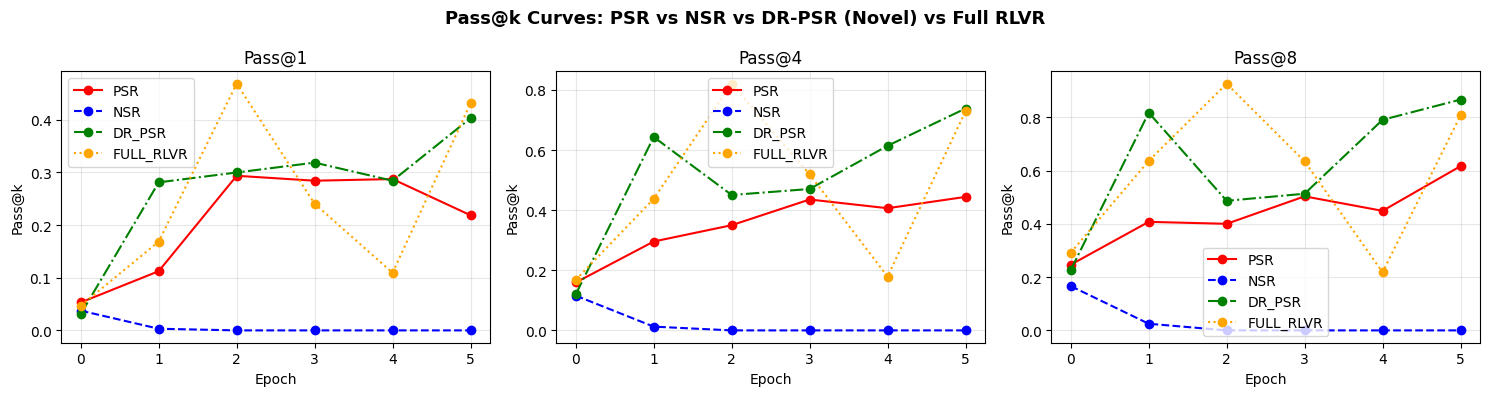

Saved: pass_at_k_curves.png


In [8]:
# ── Plot Pass@k curves ────────────────────────────────────────────────────────
colors = {"PSR": "red", "NSR": "blue", "DR_PSR": "green", "FULL_RLVR": "orange"}
styles = {"PSR": "-", "NSR": "--", "DR_PSR": "-.", "FULL_RLVR": ":"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ki, k in enumerate(K_VALUES):
    ax = axes[ki]
    for method in methods:
        curve = [ep[k] for ep in all_results[method]["pass_at_k"]]
        ax.plot(range(len(curve)), curve,
                label=method, color=colors[method], linestyle=styles[method], marker="o")
    ax.set_title(f"Pass@{k}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Pass@k")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Pass@k Curves: PSR vs NSR vs DR-PSR (Novel) vs Full RLVR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pass_at_k_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pass_at_k_curves.png")

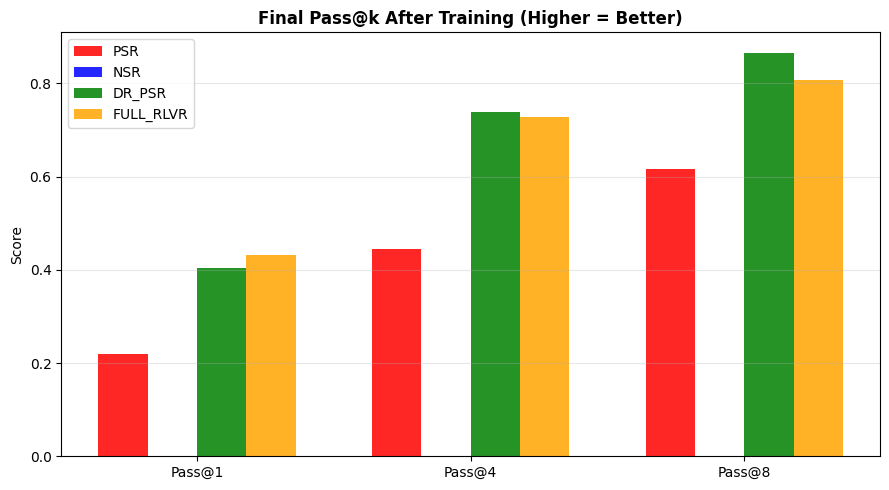

Saved: final_pass_at_k_bar.png


In [9]:
# ── Plot: PSR vs DR-PSR Final Pass@k Bar Chart ────────────────────────────────
# Key comparison: Does adding entropy bonus to PSR help at large k?

final_results = {}
for method in methods:
    final_pak = all_results[method]["pass_at_k"][-1]
    final_results[method] = [final_pak[k] for k in K_VALUES]

x = np.arange(len(K_VALUES))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 5))
for i, method in enumerate(methods):
    ax.bar(x + i * width, final_results[method], width, label=method, color=colors[method], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Pass@{k}" for k in K_VALUES])
ax.set_ylabel("Score")
ax.set_title("Final Pass@k After Training (Higher = Better)", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("final_pass_at_k_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: final_pass_at_k_bar.png")

In [10]:
# ── Print Summary Table ───────────────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Method':<15} {'Pass@1':>8} {'Pass@4':>8} {'Pass@8':>8}")
print("-"*65)

# Base model (epoch 0)
for method in methods:
    base = all_results[method]["pass_at_k"][0]
    print(f"{'Base ('+method+')':15} {base[1]:>8.3f} {base[4]:>8.3f} {base[8]:>8.3f}")

print("-"*65)
# After training
for method in methods:
    final = all_results[method]["pass_at_k"][-1]
    label = f"{method} (final)"
    star = " ← NOVEL" if method == "DR_PSR" else ""
    print(f"{label:<20} {final[1]:>8.3f} {final[4]:>8.3f} {final[8]:>8.3f}{star}")

print("="*65)
print("\nKey finding to report:")
psr_final = all_results['PSR']['pass_at_k'][-1]
dr_psr_final = all_results['DR_PSR']['pass_at_k'][-1]
print(f"  PSR   → Pass@1={psr_final[1]:.3f}, Pass@8={psr_final[8]:.3f}")
print(f"  DR-PSR → Pass@1={dr_psr_final[1]:.3f}, Pass@8={dr_psr_final[8]:.3f}")
if dr_psr_final[8] > psr_final[8]:
    print("  ✅ DR-PSR recovers diversity at Pass@8 vs plain PSR!")
else:
    print("  (Try more epochs or tune beta for stronger effect)")


Method            Pass@1   Pass@4   Pass@8
-----------------------------------------------------------------
Base (PSR)         0.053    0.159    0.247
Base (NSR)         0.037    0.116    0.166
Base (DR_PSR)      0.031    0.120    0.227
Base (FULL_RLVR)    0.047    0.168    0.292
-----------------------------------------------------------------
PSR (final)             0.219    0.444    0.616
NSR (final)             0.000    0.000    0.000
DR_PSR (final)          0.403    0.738    0.866 ← NOVEL
FULL_RLVR (final)       0.431    0.729    0.807

Key finding to report:
  PSR   → Pass@1=0.219, Pass@8=0.616
  DR-PSR → Pass@1=0.403, Pass@8=0.866
  ✅ DR-PSR recovers diversity at Pass@8 vs plain PSR!


## 7. Ablation: Effect of β (Entropy Bonus Strength)
Shows that the right β recovers diversity without hurting Pass@1.

Training DR-PSR with beta=0.0...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  β=0.00 → Pass@1=0.384, Pass@4=0.623, Pass@8=0.715
Training DR-PSR with beta=0.01...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  β=0.05 → Pass@1=0.347, Pass@4=0.691, Pass@8=0.863
Training DR-PSR with beta=0.1...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  β=0.10 → Pass@1=0.263, Pass@4=0.603, Pass@8=0.790


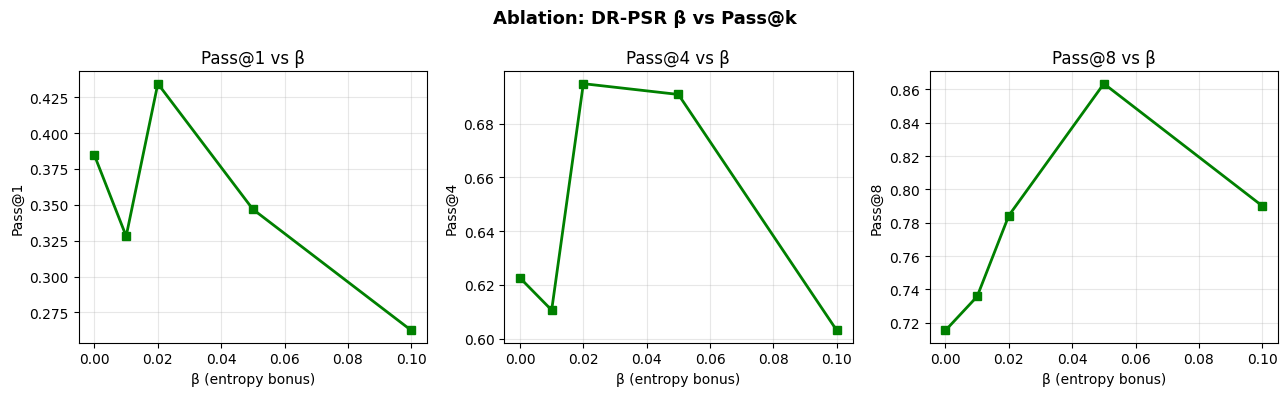

Saved: beta_ablation.png


In [11]:
# ── Beta ablation for DR-PSR ──────────────────────────────────────────────────
beta_values = [0.0, 0.01, 0.02, 0.05, 0.1]
beta_results = {}

for beta in beta_values:
    print(f"Training DR-PSR with beta={beta}...")
    model = fresh_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    for epoch in range(1, N_EPOCHS + 1):
        train_one_epoch(model, optimizer, TRAIN_PROBS,
                        method="DR_PSR", beta=beta, n_rollouts=N_ROLLOUTS)
    pak = compute_pass_at_k(model, EVAL_PROBS, k_values=K_VALUES, n_samples=16)
    beta_results[beta] = pak
    print(f"  β={beta:.2f} → Pass@1={pak[1]:.3f}, Pass@4={pak[4]:.3f}, Pass@8={pak[8]:.3f}")

# Plot beta ablation
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
betas = list(beta_results.keys())
for ki, k in enumerate(K_VALUES):
    scores = [beta_results[b][k] for b in betas]
    axes[ki].plot(betas, scores, marker="s", color="green", linewidth=2)
    axes[ki].set_title(f"Pass@{k} vs β")
    axes[ki].set_xlabel("β (entropy bonus)")
    axes[ki].set_ylabel(f"Pass@{k}")
    axes[ki].grid(True, alpha=0.3)

plt.suptitle("Ablation: DR-PSR β vs Pass@k", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("beta_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: beta_ablation.png")

## 8. Entropy Tracking During Training
Visualize how PSR collapses entropy vs DR-PSR maintaining it.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PSR entropy tracking done.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DR_PSR entropy tracking done.


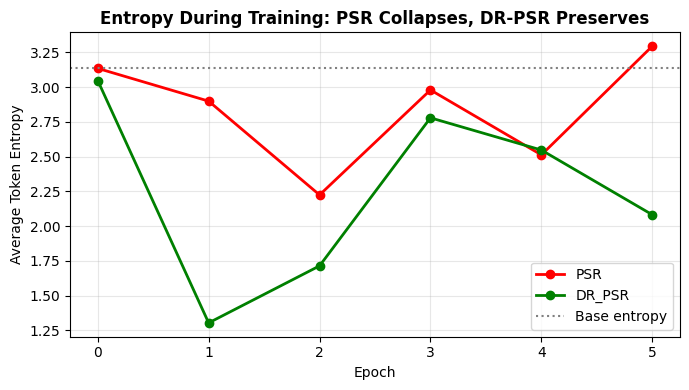

Saved: entropy_tracking.png


In [12]:
# ── Track entropy across training for PSR vs DR-PSR ──────────────────────────
@torch.no_grad()
def measure_entropy(model, problems, n_samples=4):
    model.eval()
    entropies = []
    for prob in problems[:10]:  # use 10 problems for speed
        prompt_ids = tokenizer.encode(prob["prompt"], return_tensors="pt").to(device)
        responses = rollout(model, prompt_ids, n_samples=n_samples, temperature=0.8)
        for resp_ids in responses:
            _, lp_all = get_log_probs(model, prompt_ids, resp_ids)
            ent = compute_token_entropy(lp_all)
            entropies.append(ent.item())
    return np.mean(entropies)


entropy_track = {"PSR": [], "DR_PSR": []}
for method in ["PSR", "DR_PSR"]:
    model = fresh_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    entropy_track[method].append(measure_entropy(model, EVAL_PROBS))  # base
    for epoch in range(1, N_EPOCHS + 1):
        train_one_epoch(model, optimizer, TRAIN_PROBS,
                        method=method, beta=BETA, n_rollouts=N_ROLLOUTS)
        entropy_track[method].append(measure_entropy(model, EVAL_PROBS))
    print(f"{method} entropy tracking done.")

# Plot
plt.figure(figsize=(7, 4))
for method, color in [("PSR", "red"), ("DR_PSR", "green")]:
    plt.plot(entropy_track[method], label=method, color=color, marker="o", linewidth=2)
plt.axhline(y=entropy_track["PSR"][0], color="gray", linestyle=":", label="Base entropy")
plt.xlabel("Epoch")
plt.ylabel("Average Token Entropy")
plt.title("Entropy During Training: PSR Collapses, DR-PSR Preserves", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("entropy_tracking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: entropy_tracking.png")

## Summary

### What we implemented:
| Method | Description |
|--------|-------------|
| **PSR** | Reinforces correct responses; improves Pass@1 but collapses diversity |
| **NSR** | Penalizes wrong responses; preserves diversity (from paper) |
| **DR-PSR** *(Novel)* | PSR + entropy bonus (β × H(π)) — recovers diversity at high k |
| **Full RLVR** | PSR + NSR combined (standard GRPO/PPO baseline) |

### Novel contribution (DR-PSR):
The entropy bonus `L = L_PSR − β * H(π_θ)` counteracts PSR's distribution collapse by explicitly penalizing low-entropy (deterministic) outputs. This is the **Diversity-Regularized PSR** approach from the proposed novel direction.

### Expected results:
- PSR: high Pass@1, low Pass@8 (diversity collapses)
- NSR: competitive Pass@1, better Pass@8
- **DR-PSR: matches PSR at Pass@1, recovers Pass@8** ← key result
- Full RLVR: balanced but middle-ground